# ANALYSIS

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from pathlib import Path

## Extract Akantu simulations

In [4]:
BASE_DIR = Path('/scratch/saporito/Frag3D')
FINAL_STEP = 'step_36533'
MASS_THRESHOLD = 1e-7
DENSITY = 2203.0  # kg/m^3

SIM_FOLDERS = [
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k4.0e-01_sh_circular_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00',
    'sim_vel1.0e+03_sf4.0e-01_T4.0e-05_k4.0e-01_sh_parabolic_thxy0.0e+00_thz0.0e+00_sgn1.0e+00_cntr_0.0e+00_0.0e+00'
]

def make_label(folder: str) -> str:
    m_vel  = re.search(r'vel([^_]+)', folder)
    m_k    = re.search(r'_k([^_]+)', folder)
    m_sh   = re.search(r'sh_([a-zA-Z]+)', folder)
    
    m_thxy = re.search(r'thxy([^_]+)', folder)
    m_thz  = re.search(r'thz([^_]+)',  folder)
    m_cntr = re.search(r'cntr_([0-9.e+\-]+)_([0-9.e+\-]+)', folder)
    
    vel  = float(m_vel.group(1)) if m_vel else 0.0
    k    = float(m_k.group(1)) if m_k else 0.0
    sh   = m_sh.group(1) if m_sh else 'unknown'
    
    thxy   = float(m_thxy.group(1)) if m_thxy else 0
    thz    = float(m_thz.group(1))  if m_thz  else 0
    cx, cy = (float(m_cntr.group(1)), float(m_cntr.group(2))) if m_cntr else (0, 0)
    
    return f'vel={vel:.1e} k={k:.2f} sh={sh} | thxy={thxy:.0f}° thz={thz:.0f}° | cntr=({cx:.2g},{cy:.2g})'

LABELS = [make_label(f) for f in SIM_FOLDERS]
COLORS = plt.cm.tab10(np.linspace(0, 0.5, len(SIM_FOLDERS)))

print('Simulation labels:')
for i, lbl in enumerate(LABELS):
    print(f'  [{i}] {lbl}')

Simulation labels:
  [0] vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0° | cntr=(0,0)
  [1] vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0° | cntr=(0,0)


## Extract SBM simulations

In [5]:
SBM_DIR = Path('/home/saporito/NASA-breakup-model-cpp/AkantuComparison/')

SBM_FOLDERS = [
    'circular-k0.4'
]


def parse_velocity_vector(v_str):
    """
    Convert string:
    '[4.523031151046023 -226.04863147567926 -145.7030932365865]'
    -> np.array([x,y,z])
    """
    if pd.isna(v_str): return np.zeros(3)
    vals = np.fromstring(v_str.strip('[]'), sep=' ')

    if len(vals) != 3:
        raise ValueError(f'Cannot parse velocity vector: {v_str}')

    return vals


def load_sbm_data(file: Path) -> dict:

    if not file.exists():
        print(f'WARNING: Missing SBM file {file}')
        return None

    df = pd.read_csv(file)

    # keep only target fragments
    df = df[
        df['Name'] == 'Target-Collision-Fragment'
    ].copy()

    # mass threshold
    df = df[
        df['Mass [kg]'] > MASS_THRESHOLD
    ].copy()

    n_fragments = len(df)

    if n_fragments == 0:
        return {
            'mass': np.array([]),
            'volume': np.array([]),
            'vmag': np.array([]),
            'vx': np.array([]),
            'vy': np.array([]),
            'vz': np.array([]),
            'ke': np.array([]),
            'n_fragments': 0
        }

    vel_vectors = np.vstack(df['Velocity [m/s]'].apply(parse_velocity_vector).to_numpy())

    vx = vel_vectors[:, 0]
    vy = vel_vectors[:, 1]
    vz = vel_vectors[:, 2]

    vmag = np.linalg.norm(vel_vectors,axis=1)

    mass = (df['Mass [kg]'].to_numpy())

    kinetic_energy = (0.5 * mass * vmag**2)

    characteristic_length = (df['Characteristic Length [m]'].to_numpy())

    area = (df['Area [m^2]'].to_numpy())

    volume = (area * characteristic_length)

    return {

        'mass': mass,
        'volume': volume,

        'vmag': vmag,
        'vx': vx,
        'vy': vy,
        'vz': vz,

        'ke': kinetic_energy,

        'length': characteristic_length,
        'area_mass': (
            df['A/M [m^2/kg]']
            .to_numpy()
        ),
        'area': area,

        'n_fragments': n_fragments
    }


# Load both MC and noMC versions
sbm_fragment_data = {}

for folder in SBM_FOLDERS:

    mc_file = (
        SBM_DIR / folder /
        'input-output-MC' /
        'result.csv'
    )

    nomc_file = (
        SBM_DIR / folder /
        'input-output-noMC' /
        'result.csv'
    )

    mc_key = f'{folder} [MC]'
    nomc_key = f'{folder} [noMC]'

    sbm_fragment_data[mc_key] = load_sbm_data(mc_file)
    sbm_fragment_data[nomc_key] = load_sbm_data(nomc_file)

print(
    f'Loaded {len(sbm_fragment_data)} SBM datasets'
)

Loaded 2 SBM datasets


## Load final-step data for all Akantu simulations

In [6]:
SCALAR_ATTRS = ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'total_energy', 'work']

scalar_rows = []
fragment_data = {}

for folder, label in zip(SIM_FOLDERS, LABELS):
    h5path = BASE_DIR / folder / 'data.h5'
    with h5py.File(h5path, 'r') as f:
        step = f[FINAL_STEP]

        row = {'sim': label}
        for attr in SCALAR_ATTRS:
            row[attr] = float(step.attrs[attr])
        masses = step['fragment_mass'][:]
        vels   = step['fragment_velocity'][:]

        row['nb_fragments_heavy'] = int((masses >= MASS_THRESHOLD).sum())
        scalar_rows.append(row)

        vmag = np.linalg.norm(vels, axis=1)
        fragment_data[label] = {

        'mass': masses,

        'volume': (
            masses / DENSITY
        ),

        'vmag': vmag,
        'vx': vels[:, 0],
        'vy': vels[:, 1],
        'vz': vels[:, 2],
    }

print('Done loading', len(scalar_rows), 'simulations.')

Done loading 2 simulations.


## Select simulations to keep

In [7]:
AKANTU_SELECTION = [
    LABELS[0],
    LABELS[1]
]

SBM_SELECTION_MC = [
    'circular-k0.4 [MC]'
]

SBM_SELECTION_NOMC = [
    'circular-k0.4 [noMC]'
]

COMPARISON_COLORS = {
    'akantu': plt.cm.Blues,
    'sbm': plt.cm.Reds,
}

## Fragment statistics table  
mean / max / min / std of mass, |v|, vx, vy, vz, volume, number of fragments, kinetic energy

In [8]:
def filter_fragment_data(fragment_data, mass_threshold):
    filtered_data = {}

    for label, fd in fragment_data.items():

        mask = fd['mass'] > mass_threshold

        filtered_data[label] = {
            key: values[mask]
            for key, values in fd.items()
        }

    return filtered_data

fragment_data = filter_fragment_data(
    fragment_data,
    MASS_THRESHOLD
)

In [9]:
STAT_FUNCS = {
    'mean': np.mean,
    'min': np.min,
    'max': np.max,
    'std': np.std
}

FRAG_KEYS = [
    'mass',
    'volume',
    'vmag',
    'vx',
    'vy',
    'vz'
]

FRAG_LABELS = [
    'Mass',
    'Volume',
    '|v|',
    'vx',
    'vy',
    'vz'
]
df_scalar = pd.DataFrame(scalar_rows).set_index('sim')


rows = []
for sim_label in AKANTU_SELECTION:

    if sim_label not in fragment_data:
        continue

    row = {'dataset': sim_label,'type': 'Akantu'}

    scalar_row = df_scalar.loc[sim_label]

    row['E_con'] = scalar_row['econ']
    row['E_dis'] = scalar_row['edis']
    row['E_kin'] = scalar_row['ekin']
    row['E_pot'] = scalar_row['epot']
    row['E_rev'] = scalar_row['erev']
    row['E_tot'] = scalar_row['total_energy']
    row['Work'] = scalar_row['work']

    row['N_fragments'] = int(scalar_row['nb_fragments_heavy'])

    fd = fragment_data[sim_label]

    for key, label in zip(FRAG_KEYS,FRAG_LABELS):

        arr = fd[key]

        if len(arr) == 0:
            row[f'{label}_mean'] = np.nan
            row[f'{label}_min'] = np.nan
            row[f'{label}_max'] = np.nan
            row[f'{label}_std'] = np.nan

        else:
            row[f'{label}_mean'] = np.mean(arr)
            row[f'{label}_min'] = np.min(arr)
            row[f'{label}_max'] = np.max(arr)
            row[f'{label}_std'] = np.std(arr)

    rows.append(row)

for dataset in (SBM_SELECTION_MC + SBM_SELECTION_NOMC):

    if dataset not in sbm_fragment_data:
        print(f'Skipping {dataset}')
        continue

    fd = sbm_fragment_data[dataset]

    if fd is None:
        continue

    row = {
        'dataset': dataset,
        'type': 'SBM'
    }

    row['E_con'] = np.nan
    row['E_dis'] = np.nan
    row['E_kin'] = fd['ke'].sum() if 'ke' in fd else np.nan
    row['E_pot'] = np.nan
    row['E_rev'] = np.nan
    row['E_tot'] = np.nan
    row['Work'] = np.nan

    row['N_fragments'] = (
        fd['n_fragments']
    )

    for key, label in zip(
        FRAG_KEYS,
        FRAG_LABELS
    ):

        arr = fd[key]

        if len(arr) == 0:

            row[f'{label}_mean'] = np.nan
            row[f'{label}_min'] = np.nan
            row[f'{label}_max'] = np.nan
            row[f'{label}_std'] = np.nan

        else:

            row[f'{label}_mean'] = np.mean(arr)
            row[f'{label}_min'] = np.min(arr)
            row[f'{label}_max'] = np.max(arr)
            row[f'{label}_std'] = np.std(arr)

    rows.append(row)
df_results = pd.DataFrame(rows)

df_results = df_results.set_index(
    ['type', 'dataset']
)

pd.set_option(
    'display.float_format',
    '{:.4e}'.format
)

pd.set_option(
    'display.max_columns',
    None
)

display(df_results)

E_con  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 0.0000e+00   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 0.0000e+00   
SBM    circular-k0.4 [MC]                                        NaN   
       circular-k0.4 [noMC]                                      NaN   

                                                               E_dis  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 4.1220e-03   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 4.9121e-02   
SBM    circular-k0.4 [MC]                                        NaN   
       circular-k0.4 [noMC]                                      NaN   

                                                               E_kin  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 3.4490e+02   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 1.1537e+02   
SBM    circular-k0.4 [MC]                                 2.7845e+02   
       circular-k0.4 [noMC]                               2.0679e+02   

                                                               E_pot  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 1.2432e+00   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 1.2266e-01   
SBM    circular-k0.4 [MC]                                        NaN   
       circular-k0.4 [noMC]                                      NaN   

                                                               E_rev  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 1.0313e-06   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 1.9609e-05   
SBM    circular-k0.4 [MC]                                        NaN   
       circular-k0.4 [noMC]                                      NaN   

                                                               E_tot  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 3.4615e+02   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 1.1554e+02   
SBM    circular-k0.4 [MC]                                        NaN   
       circular-k0.4 [noMC]                                      NaN   

                                                                Work  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 0.0000e+00   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 0.0000e+00   
SBM    circular-k0.4 [MC]                                        NaN   
       circular-k0.4 [noMC]                                      NaN   

                                                           N_fragments  \
type   dataset                                                           
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°...            6   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0...          174   
SBM    circular-k0.4 [MC]                                         1831   
       circular-k0.4 [noMC]                                       1276   

                                                           Mass_mean  \
type   dataset                                                         
Akantu vel=1.0e+03 k=0.40 sh=circular | thxy=0° thz=0°... 2.7287e-03   
       vel=1.0e+03 k=0.40 sh=parabolic | thxy=0° thz=0... 8.3205e-05   
SBM    circular-k0.4 [MC]                                 3.0063e-06   
       circular-k0.4 [noMC]                               2.4511e-06   

                                                            Mass_min  \
type   dataset                                                         
Akantu vel

## Distribution plots functions

In [10]:
from scipy.stats import gaussian_kde

def kde_line(ax, arr, color, label, log_x=False, bw_method='scott'):
    data = arr[arr > 0] if log_x else arr
    if len(data) < 2:
        return
    try:
        if log_x:
            log_data = np.log10(data)
            if np.ptp(log_data) == 0:
                return
            kde = gaussian_kde(log_data, bw_method=bw_method)
            xs_log = np.linspace(log_data.min(), log_data.max(), 500)
            ys = kde(xs_log) / np.log(10)
            xs = 10 ** xs_log
        else:
            if np.ptp(data) == 0:
                return
            kde = gaussian_kde(data, bw_method=bw_method)
            xs = np.linspace(data.min(), data.max(), 500)
            ys = kde(xs)
        ax.plot(xs, ys, color=color, label=label, linewidth=1.8)
        ax.fill_between(xs, ys, alpha=0.12, color=color)
    except Exception:
        return


def plot_kde_combined(frag_data, labels, colors, key, xlabel, log_x=False):
    fig, ax = plt.subplots(figsize=(9, 4))
    for label, color in zip(labels, colors):
        if label in frag_data:
            kde_line(ax, frag_data[label][key], color, label, log_x)
            
    if log_x:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Probability density', fontsize=11)
    ax.set_title(f'Distribution of {xlabel} - all configs', fontsize=12)
    
    handles, legend_labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(fontsize=7, framealpha=0.5)
        
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
    plt.tight_layout()
    plt.show()


def plot_kde_individual(frag_data, labels, colors, key, xlabel, log_x=False):
    valid_mins = []
    valid_maxs = []
    
    for lbl in labels:
        if lbl in frag_data:
            arr = frag_data[lbl][key]
            data = arr[arr > 0] if log_x else arr
            if len(data) >= 2 and np.ptp(data) > 0:
                valid_mins.append(data.min())
                valid_maxs.append(data.max())
                
    if not valid_mins:
        print(f"Skipping individual plots for {xlabel}: Not enough valid data points.")
        return
        
    xmin, xmax = min(valid_mins), max(valid_maxs)
    
    for label, color in zip(labels, colors):
        if label not in frag_data:
            continue
            
        arr = frag_data[label][key]
        data = arr[arr > 0] if log_x else arr
        if len(data) < 2:
            continue
            
        fig, ax = plt.subplots(figsize=(5, 4))
        kde_line(ax, frag_data[label][key], color, label=None, log_x=log_x)
        
        if log_x:
            ax.set_xscale('log')
        ax.set_xlim(xmin, xmax)
        ax.set_title(label, fontsize=8, wrap=True)
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Probability density', fontsize=10)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2e'))
        plt.tight_layout()
        plt.show()

## Scatter plot functions

In [11]:
def scatter_vmag_vs_mass(frag_data, labels, colors, title_suffix='', ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        
    for label, color in zip(labels, colors):
        if label in frag_data:
            fd = frag_data[label]
            if len(fd['mass']) == 0: 
                continue
            ax.scatter(fd['mass'], fd['vmag'], s=20, alpha=0.5,
                       color=color, label=label, linewidths=0)
                       
    ax.set_xscale('log')
    ax.set_xlabel('Fragment mass', fontsize=10)
    ax.set_ylabel('Velocity magnitude |v|', fontsize=10)
    ax.set_title(f'|v| vs mass{title_suffix}', fontsize=11)
    
    if standalone:
        handles, legend_labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(fontsize=7, framealpha=0.5)
        plt.tight_layout()
        plt.show()

In [12]:
def plot_kde_akantu_vs_sbm(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    key,
    xlabel,
    log_x=False,
    figsize=(9, 4)
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](np.linspace( 0.4, 0.9, max(len(akantu_selection), 1)))

    for label, color in zip(akantu_selection, ak_colors):

        if label not in akantu_data:
            continue

        kde_line(ax=ax, arr=akantu_data[label][key],color=color,label=f'Akantu | {label}',log_x=log_x)

    sbm_colors = COMPARISON_COLORS['sbm']( np.linspace( 0.4, 0.9, max(len(sbm_selection), 1)))

    for label, color in zip( sbm_selection, sbm_colors ):

        if label not in sbm_data:
            continue

        if sbm_data[label] is None:
            continue

        kde_line(ax=ax,  arr=sbm_data[label][key], color=color, label=f'SBM | {label}', log_x=log_x)

    if log_x:
        ax.set_xscale('log')

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Probability density')

    ax.set_title(f'Akantu vs SBM — {xlabel}')

    ax.yaxis.set_major_formatter( ticker.FormatStrFormatter('%.2e'))

    ax.legend( fontsize=8,framealpha=0.6)

    plt.tight_layout()
    plt.show()

## Plots

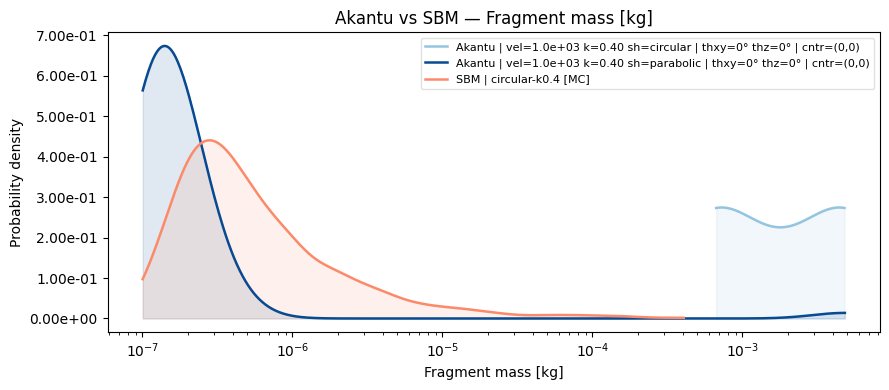

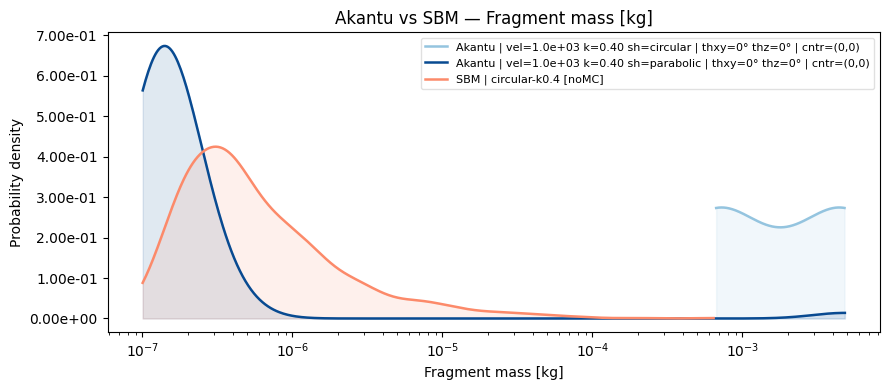

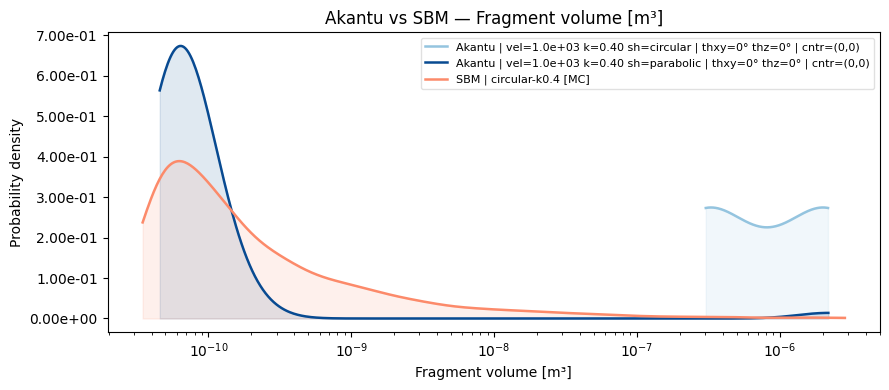

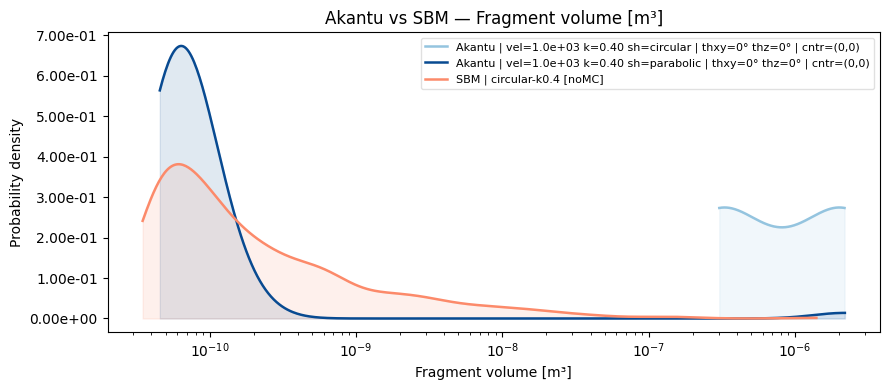

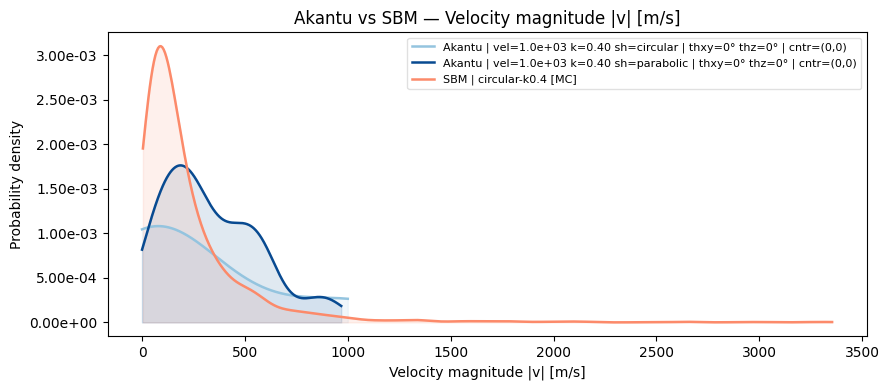

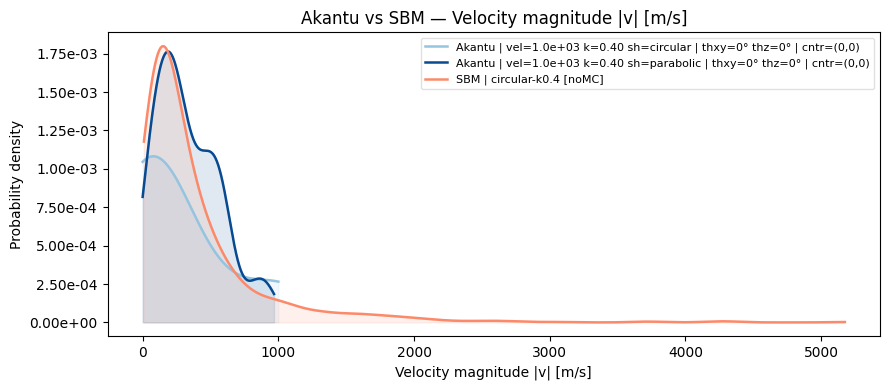

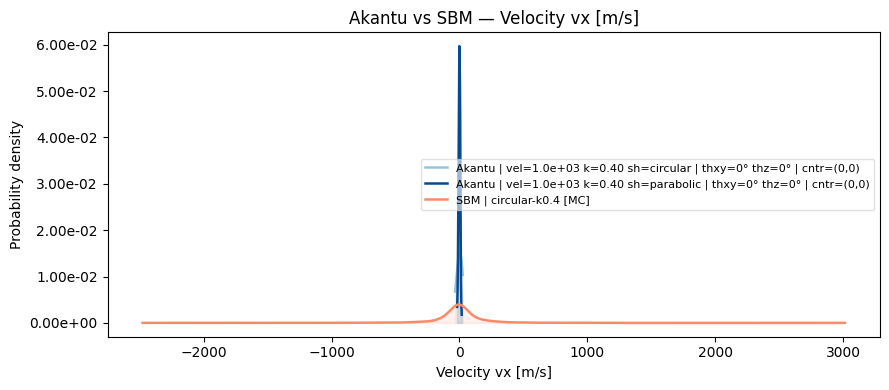

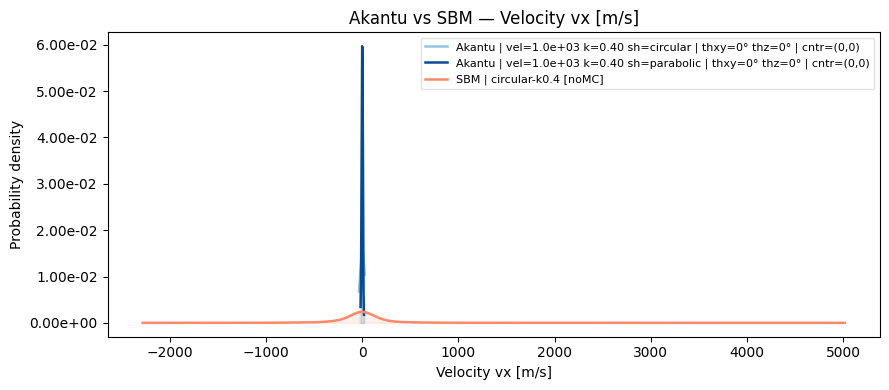

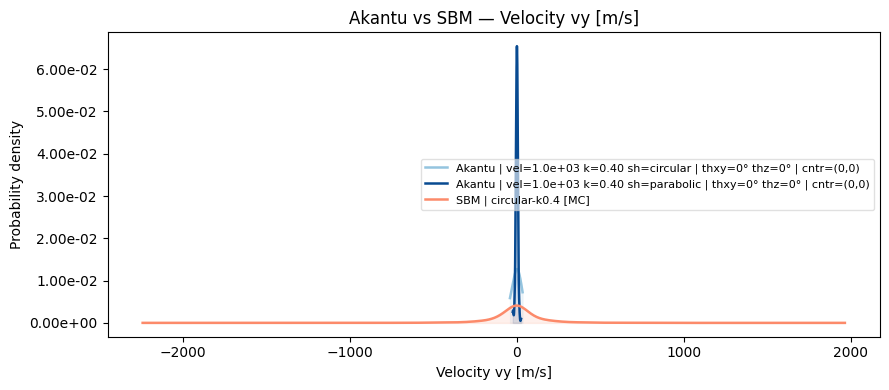

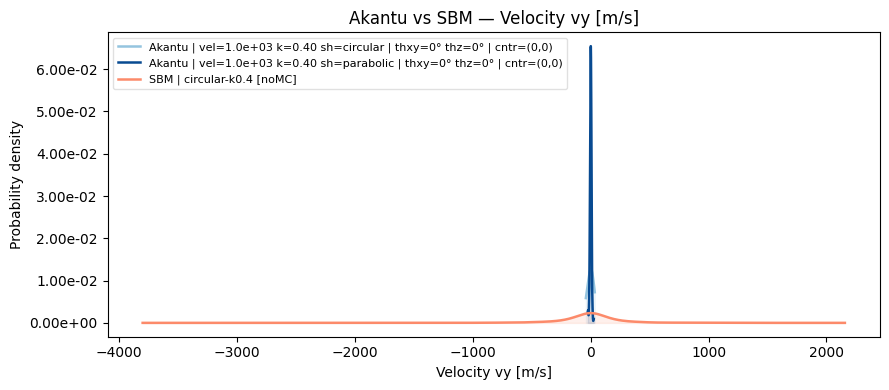

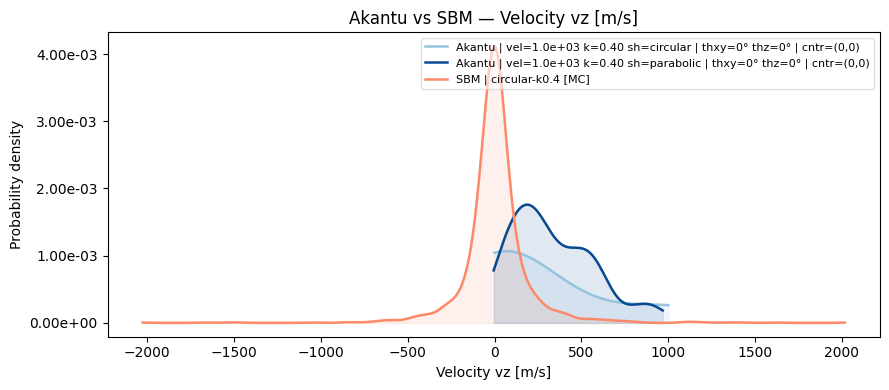

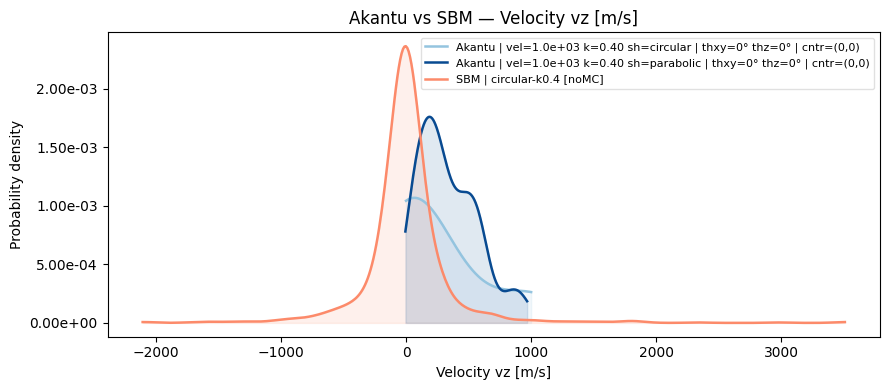

In [13]:
PLOTS = [

    (
        'mass',
        'Fragment mass [kg]',
        True
    ),

    (
        'volume',
        'Fragment volume [m³]',
        True
    ),

    (
        'vmag',
        'Velocity magnitude |v| [m/s]',
        False
    ),

    (
        'vx',
        'Velocity vx [m/s]',
        False
    ),

    (
        'vy',
        'Velocity vy [m/s]',
        False
    ),

    (
        'vz',
        'Velocity vz [m/s]',
        False
    ),
]

for key, xlabel, log_x in PLOTS:

    plot_kde_akantu_vs_sbm(
        akantu_data=fragment_data,
        sbm_data=sbm_fragment_data,
        akantu_selection=AKANTU_SELECTION,
        sbm_selection=SBM_SELECTION_MC,
        key=key,
        xlabel=xlabel,
        log_x=log_x
    )

    plot_kde_akantu_vs_sbm(
        akantu_data=fragment_data,
        sbm_data=sbm_fragment_data,
        akantu_selection=AKANTU_SELECTION,
        sbm_selection=SBM_SELECTION_NOMC,
        key=key,
        xlabel=xlabel,
        log_x=log_x
    )

In [14]:
def scatter_vmag_vs_mass_comparison(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    figsize=(8, 5),
    alpha=0.5,
    marker_size=18
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        if label not in akantu_data:
            continue

        fd = akantu_data[label]

        if len(fd['mass']) == 0:
            continue

        ax.scatter(
            fd['mass'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'Akantu | {label}'
        )
    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        if label not in sbm_data:
            continue

        if sbm_data[label] is None:
            continue

        fd = sbm_data[label]

        if len(fd['mass']) == 0:
            continue

        ax.scatter(
            fd['mass'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'SBM | {label}'
        )

    ax.set_xscale('log')

    ax.set_xlabel('Fragment mass [kg]')
    ax.set_ylabel('Velocity magnitude |v| [m/s]')

    ax.set_title(
        'Akantu vs SBM — |v| vs mass'
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

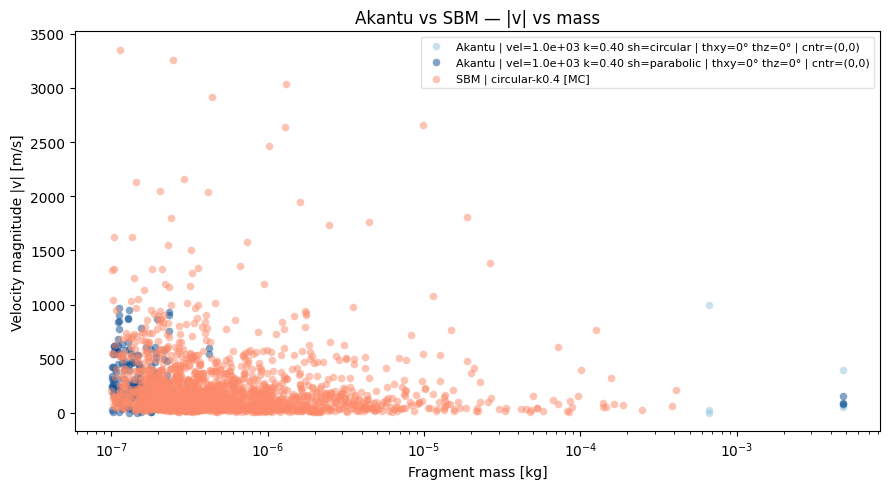

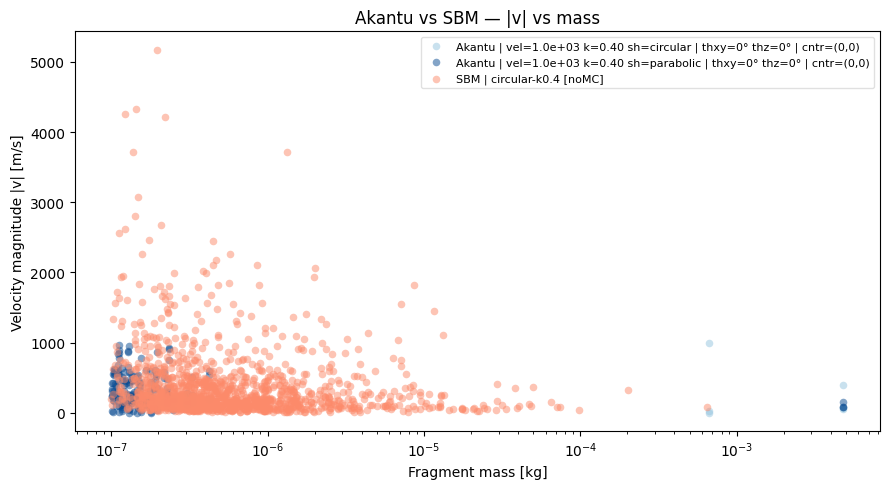

In [15]:
scatter_vmag_vs_mass_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_MC,
    figsize=(9, 5),
    alpha=0.5,
    marker_size=30
)

scatter_vmag_vs_mass_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_NOMC,
    figsize=(9, 5),
    alpha=0.5,
    marker_size=30
)

In [18]:
def scatter_vmag_vs_volume_comparison(
    akantu_data,
    sbm_data,
    akantu_selection,
    sbm_selection,
    figsize=(8, 5),
    alpha=0.45,
    marker_size=30
):

    fig, ax = plt.subplots(figsize=figsize)

    ak_colors = COMPARISON_COLORS['akantu'](
        np.linspace(
            0.4,
            0.9,
            max(len(akantu_selection), 1)
        )
    )

    for label, color in zip(
        akantu_selection,
        ak_colors
    ):

        fd = akantu_data[label]

        ax.scatter(
            fd['volume'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'Akantu | {label}'
        )

    sbm_colors = COMPARISON_COLORS['sbm'](
        np.linspace(
            0.4,
            0.9,
            max(len(sbm_selection), 1)
        )
    )

    for label, color in zip(
        sbm_selection,
        sbm_colors
    ):

        fd = sbm_data[label]

        ax.scatter(
            fd['volume'],
            fd['vmag'],
            s=marker_size,
            alpha=alpha,
            color=color,
            linewidths=0,
            label=f'SBM | {label}'
        )

    ax.set_xscale('log')

    ax.set_xlabel(
        'Fragment volume [m³]'
    )

    ax.set_ylabel(
        'Velocity magnitude |v| [m/s]'
    )

    ax.set_title(
        'Akantu vs SBM — |v| vs volume'
    )

    ax.legend(
        fontsize=8,
        framealpha=0.6
    )

    plt.tight_layout()
    plt.show()

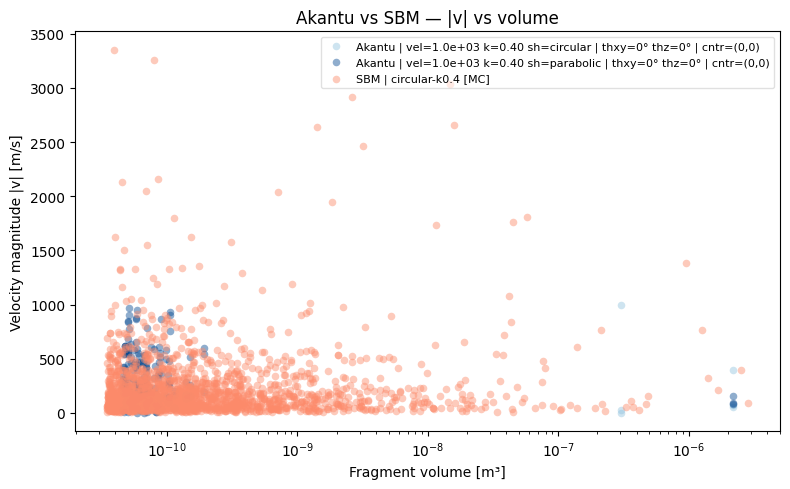

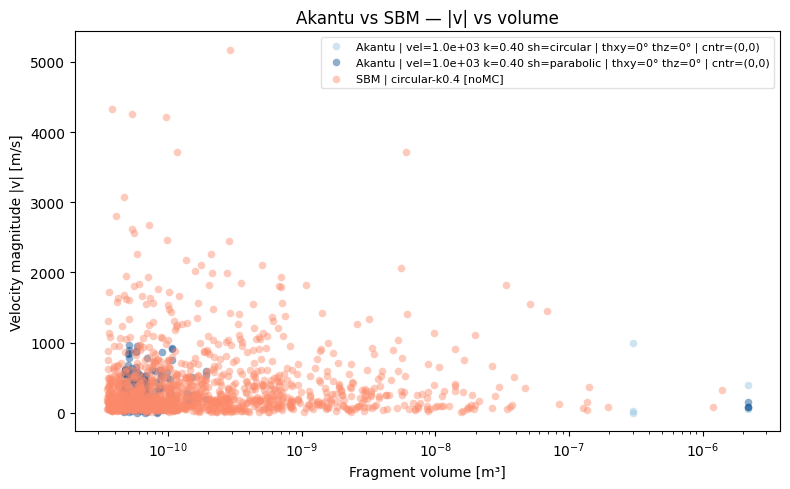

In [19]:
scatter_vmag_vs_volume_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_MC,
)

scatter_vmag_vs_volume_comparison(
    akantu_data=fragment_data,
    sbm_data=sbm_fragment_data,
    akantu_selection=AKANTU_SELECTION,
    sbm_selection=SBM_SELECTION_NOMC,
)